# CRIME FORECASTING YORK REGION 

## Import Libraries

In [27]:
import os
import sys
import warnings
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")


## Load file

In [28]:
df = pd.read_csv(r"C:\Users\MXC3O5T\OneDrive - The Home Depot\Desktop\Calls for Service 2022 to 2024.csv")
df.head()

,Call Date,Call Time (HH:MM:SS),District,Sector,Call Type
0,20220101,21:10:30,4,42,PROPERTY DAMAGE
1,20220101,16:39:05,4,42,THEFT OF VEHICLE
2,20220101,13:28:58,1,11,FIRE
3,20220101,21:12:03,2,23,MISSING ADULT
4,20220101,17:42:44,5,53,PROPERTY DAMAGE


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 479861 entries, 0 to 479860
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   Call Date             479861 non-null  int64 
 1   Call Time (HH:MM:SS)  479861 non-null  object
 2   District              479861 non-null  object
 3   Sector                479861 non-null  object
 4   Call Type             479861 non-null  object
dtypes: int64(1), object(4)
memory usage: 18.3+ MB


In [30]:
# Internal canonical names we'll use throughout the codebase
CANONICAL_COLUMNS = {
    "date": "Call Date",
    "time": "Call Time (HH:MM:SS)",
    "district": "District",
    "sector": "Sector",
    "category": "Call Type",
}

# ---- 2) Validate expected columns ----
expected = list(CANONICAL_COLUMNS.values())
actual = list(df.columns)

missing = [c for c in expected if c not in actual]
extra = [c for c in actual if c not in expected]


if missing:
    raise ValueError(
        f"Missing required columns: {missing}. "
        f"Expected exactly: {expected}. Found: {actual}"
    )

# (Optional) warn if there are extras; in your case there shouldn't be any
if extra:
    print(f"Warning: unexpected columns present and will be ignored: {extra}")


 #---- 3) Normalize to internal names ----
# Create a mapping from original -> internal
to_internal = {v: k for k, v in CANONICAL_COLUMNS.items()}
df = df.rename(columns=to_internal)

# At this point, df has columns:
# ['date', 'year', 'time', 'district', 'sector', 'category']


In [31]:
df['date'] = pd.to_datetime(df['date'].astype(str), format="%Y%m%d")
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['day_of_week'] = df['date'].dt.dayofweek     # Monday=0
df['day_name'] = df['date'].dt.day_name()
df['month_name'] = df['date'].dt.month_name()
df['time'] = pd.to_datetime(df['time'], format="%H:%M:%S", errors='coerce').dt.time
df.head()

,date,time,district,sector,category,year,month,day,day_of_week,day_name,month_name
0,2022-01-01,21:10:30,4,42,PROPERTY DAMAGE,2022,1,1,5,Saturday,January
1,2022-01-01,16:39:05,4,42,THEFT OF VEHICLE,2022,1,1,5,Saturday,January
2,2022-01-01,13:28:58,1,11,FIRE,2022,1,1,5,Saturday,January
3,2022-01-01,21:12:03,2,23,MISSING ADULT,2022,1,1,5,Saturday,January
4,2022-01-01,17:42:44,5,53,PROPERTY DAMAGE,2022,1,1,5,Saturday,January


In [32]:
df.describe(include='all').transpose()

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
date,479861,NaN,NaN,NaN,2023-07-20 20:10:17.728883968,2022-01-01 00:00:00,2022-10-25 00:00:00,2023-07-27 00:00:00,2024-04-19 00:00:00,2024-12-31 00:00:00,NaN
time,479861,84001,17:06:22,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
district,479861,6,4,139223,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sector,479861,24,22,38333,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,479861,155,CHECK WELFARE,30977,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,479861.0,NaN,NaN,NaN,2023.038499,2022.0,2022.0,2023.0,2024.0,2024.0,0.809499
month,479861.0,NaN,NaN,NaN,6.674439,1.0,4.0,7.0,10.0,12.0,3.366258
day,479861.0,NaN,NaN,NaN,15.714763,1.0,8.0,16.0,23.0,31.0,8.803103
day_of_week,479861.0,NaN,NaN,NaN,2.924982,0.0,1.0,3.0,5.0,6.0,1.949703
day_name,479861,7,Friday,73906,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 479861 entries, 0 to 479860
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   date         479861 non-null  datetime64[ns]
 1   time         479861 non-null  object        
 2   district     479861 non-null  object        
 3   sector       479861 non-null  object        
 4   category     479861 non-null  object        
 5   year         479861 non-null  int32         
 6   month        479861 non-null  int32         
 7   day          479861 non-null  int32         
 8   day_of_week  479861 non-null  int32         
 9   day_name     479861 non-null  object        
 10  month_name   479861 non-null  object        
dtypes: datetime64[ns](1), int32(4), object(6)
memory usage: 32.9+ MB


# Exploratory Data Analysis

### Yearly Trend of Reported crime calls 

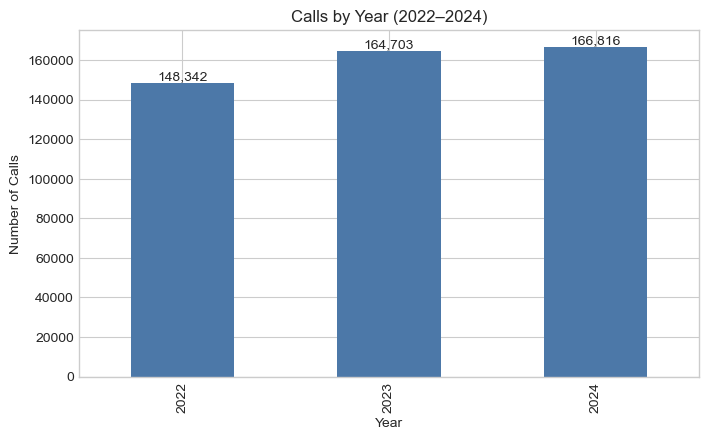

In [34]:
# --- Calls by Year ---
calls_by_year = df.groupby("year").size().rename("Calls")

fig, ax = plt.subplots(figsize=(8, 4.5))
calls_by_year.plot(kind="bar", color="#4C78A8", ax=ax)
ax.set_title("Calls by Year (2022–2024)")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Calls")
for i, v in enumerate(calls_by_year.values):
    ax.text(i, v, f"{int(v):,}", ha="center", va="bottom")
plt.show()

### YoY trend of crime calls ins per District 

In [35]:
# Understanding YoY trends per district 

import pandas as pd

# --- 1. Aggregate calls per district per year ---
district_year = df.groupby(["district", "year"]).size().unstack(fill_value=0)

# Ensure all years are included
for yr in [2022, 2023, 2024]:
    if yr not in district_year.columns:
        district_year[yr] = 0

# --- 2. Overall totals per district ---
district_year['Overall Totals'] = district_year.sum(axis=1)

# --- 3. Calculate YoY %
district_year['2022 vs 2023 YoY'] = ((district_year[2023] - district_year[2022]) / district_year[2022] * 100).round(1)
district_year['2022 vs 2024 YoY'] = ((district_year[2024] - district_year[2022]) / district_year[2022] * 100).round(1)
district_year['2023 vs 2024 YoY'] = ((district_year[2024] - district_year[2023]) / district_year[2023] * 100).round(1)

# --- 4. Rename columns ---
district_year = district_year.rename(columns={
    2022: "2022 Total Calls",
    2023: "2023 Total Calls",
    2024: "2024 Total Calls"
})

# --- 5. Add total row ---
totals = district_year[["2022 Total Calls","2023 Total Calls","2024 Total Calls","Overall Totals"]].sum()
totals["2022 vs 2023 YoY"] = ((totals['2023 Total Calls']-totals['2022 Total Calls'])/totals['2022 Total Calls']*100).round(1)
totals["2022 vs 2024 YoY"] = ((totals['2024 Total Calls']-totals['2022 Total Calls'])/totals['2022 Total Calls']*100).round(1)
totals["2023 vs 2024 YoY"] = ((totals['2024 Total Calls']-totals['2023 Total Calls'])/totals['2023 Total Calls']*100).round(1)

district_year.loc["Total"] = totals

# --- 6. Format numbers with commas & YoY with % ---
for col in ["2022 Total Calls","2023 Total Calls","2024 Total Calls","Overall Totals"]:
    district_year[col] = district_year[col].apply(lambda x: f"{int(x):,}")

for col in ["2022 vs 2023 YoY","2022 vs 2024 YoY","2023 vs 2024 YoY"]:
    district_year[col] = district_year[col].apply(lambda x: f"{x:.0f}%" if pd.notnull(x) else "")

# --- 7. Reset index to show District as a column ---
district_year = district_year.reset_index()

district_year


year,district,2022 Total Calls,2023 Total Calls,2024 Total Calls,Overall Totals,2022 vs 2023 YoY,2022 vs 2024 YoY,2023 vs 2024 YoY
0,1,"32,735","37,701","39,343","109,779",15%,20%,4%
1,2,"32,180","35,268","35,011","102,459",10%,9%,-1%
2,3,"9,034","9,837","9,939","28,810",9%,10%,1%
3,4,"43,688","48,177","47,358","139,223",10%,8%,-2%
4,5,"29,478","32,678","33,902","96,058",11%,15%,4%
5,~,"1,227","1,042","1,263","3,532",-15%,3%,21%
6,Total,"148,342","164,703","166,816","479,861",11%,12%,1%


 Total crimes captured through calls per year has been increasing with +15% growth from 2022 to 2023 and +1% growth from 2023 to 2024

### Average call per Day of Week

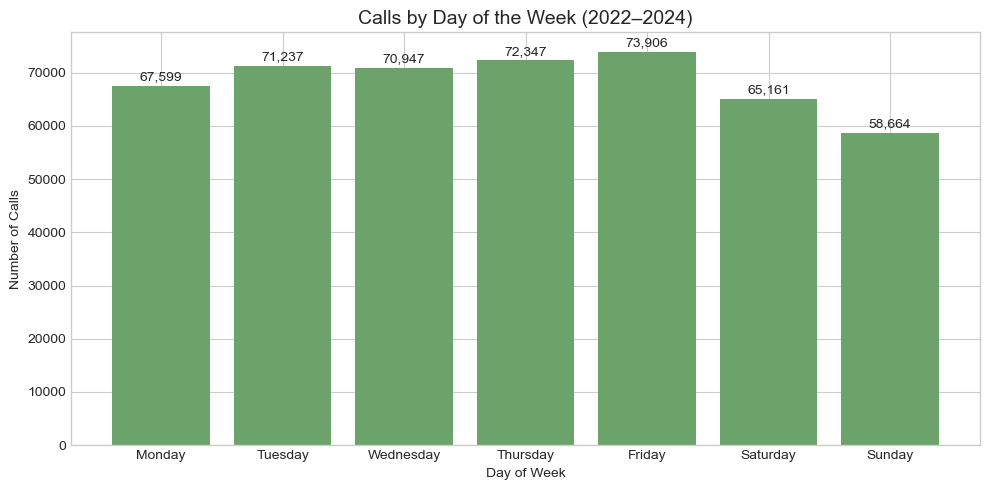

In [55]:

# --- 1. Aggregate calls by day of week ---
calls_by_day = df.groupby("day_name").size().rename("Calls")

# --- 2. Reorder days to standard week order ---
week_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
calls_by_day = calls_by_day.reindex(week_order)

# --- 3. Plot ---
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(calls_by_day.index, calls_by_day.values, color="#6BA36B")

# Add call counts at the top of each bar
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 500, f"{int(height):,}", ha='center', va='bottom', fontsize=10)

ax.set_title("Calls by Day of the Week (2022–2024)", fontsize=14)
ax.set_xlabel("Day of Week")
ax.set_ylabel("Number of Calls")
plt.tight_layout()
plt.show()


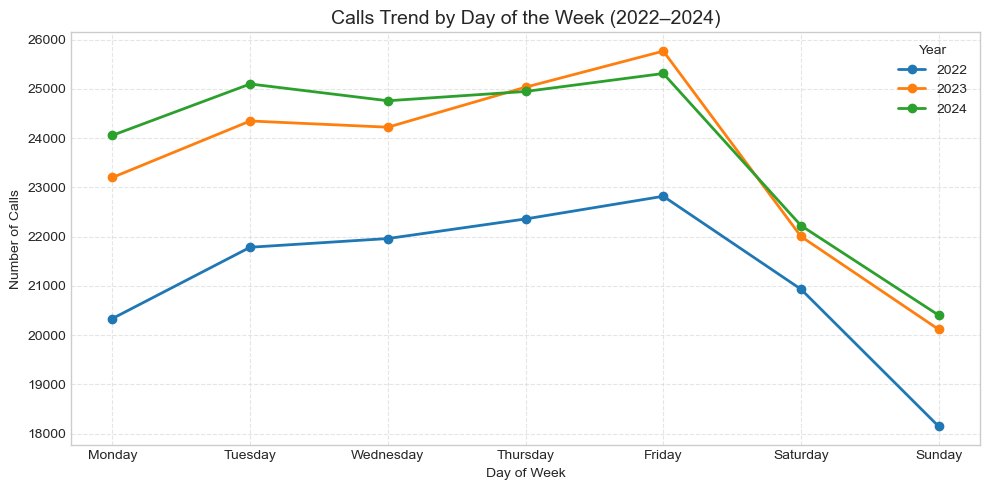

In [53]:


# --- 1. Aggregate calls by year and day of week ---
calls_weekly = df.groupby(['year', 'day_name']).size().reset_index(name='Calls')

# --- 2. Pivot so each year is a separate column ---
calls_pivot = calls_weekly.pivot(index='day_name', columns='year', values='Calls').fillna(0)

# --- 3. Reorder days to standard week order ---
week_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
calls_pivot = calls_pivot.reindex(week_order)

# --- 4. Plot ---
fig, ax = plt.subplots(figsize=(10,5))
for year in calls_pivot.columns:
    ax.plot(calls_pivot.index, calls_pivot[year], marker='o', label=str(year), linewidth=2)

ax.set_title("Calls Trend by Day of the Week (2022–2024)", fontsize=14)
ax.set_xlabel("Day of Week")
ax.set_ylabel("Number of Calls")
ax.legend(title="Year")
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### Average Calls per Month 

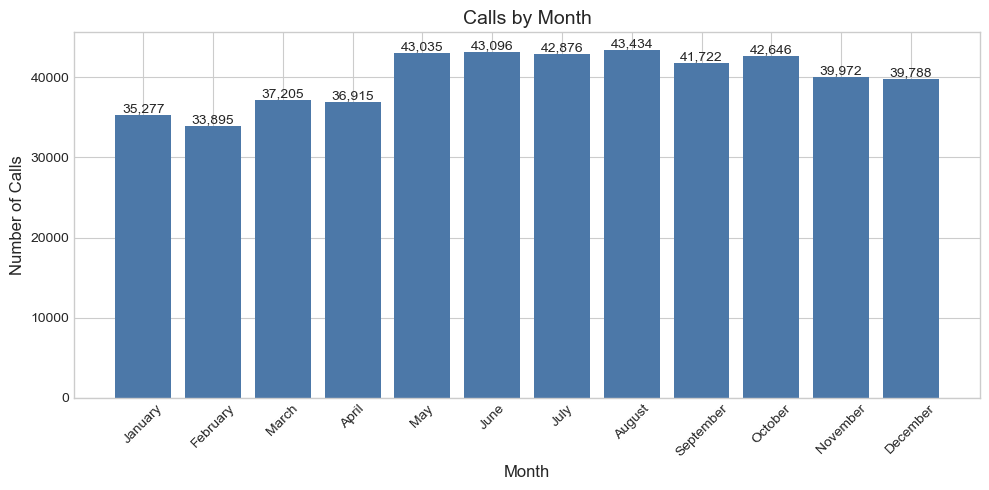

In [36]:
# --- Calls by Month ---
# Group by month and keep chronological order
calls_by_month = df.groupby("month_name").size().reindex([
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]).rename("Calls")

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(calls_by_month.index, calls_by_month.values, color="#4C78A8")  # nicer blue

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height, f"{int(height):,}",
            ha="center", va="bottom", fontsize=10)

# Titles and labels
ax.set_title("Calls by Month", fontsize=14)
ax.set_xlabel("Month",  fontsize=12)
ax.set_ylabel("Number of Calls", fontsize=12)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

August tends to have the largest call volume per month on average from 2022 to 2024

### Monthly Trends per Year 

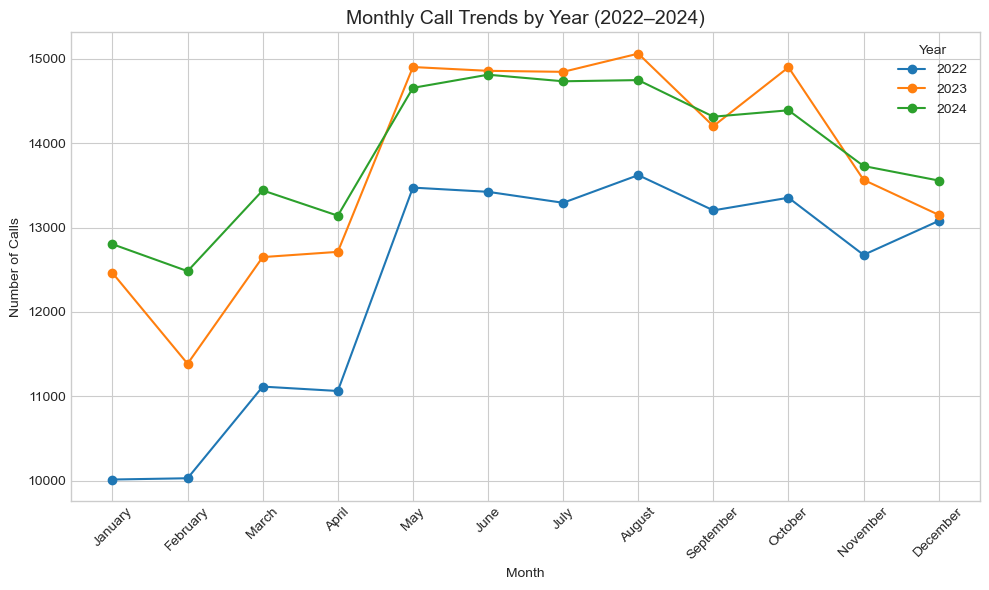

In [37]:
# Monthly trend per year to identify which months has the higest call intakes 

# --- Prepare data: group by year + month ---
month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]

monthly_calls = df.groupby(["year", "month_name"]).size().rename("Calls").reset_index()
monthly_calls['month_name'] = pd.Categorical(monthly_calls['month_name'], categories=month_order, ordered=True)

# Pivot so each year is a separate line
monthly_pivot = monthly_calls.pivot(index='month_name', columns='year', values='Calls')

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 6))

# Different line color per year
colors = {2022: "#1f77b4", 2023: "#ff7f0e", 2024: "#2ca02c"}

for year in monthly_pivot.columns:
    ax.plot(monthly_pivot.index, monthly_pivot[year], marker='o', label=str(year), color=colors[year])

ax.set_title("Monthly Call Trends by Year (2022–2024)", fontsize=14)
ax.set_xlabel("Month")
ax.set_ylabel("Number of Calls")
ax.legend(title="Year")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


June , July & August we see uptick of crime thats leads increase calls to the department 

### District Ranking for crimes reported per call

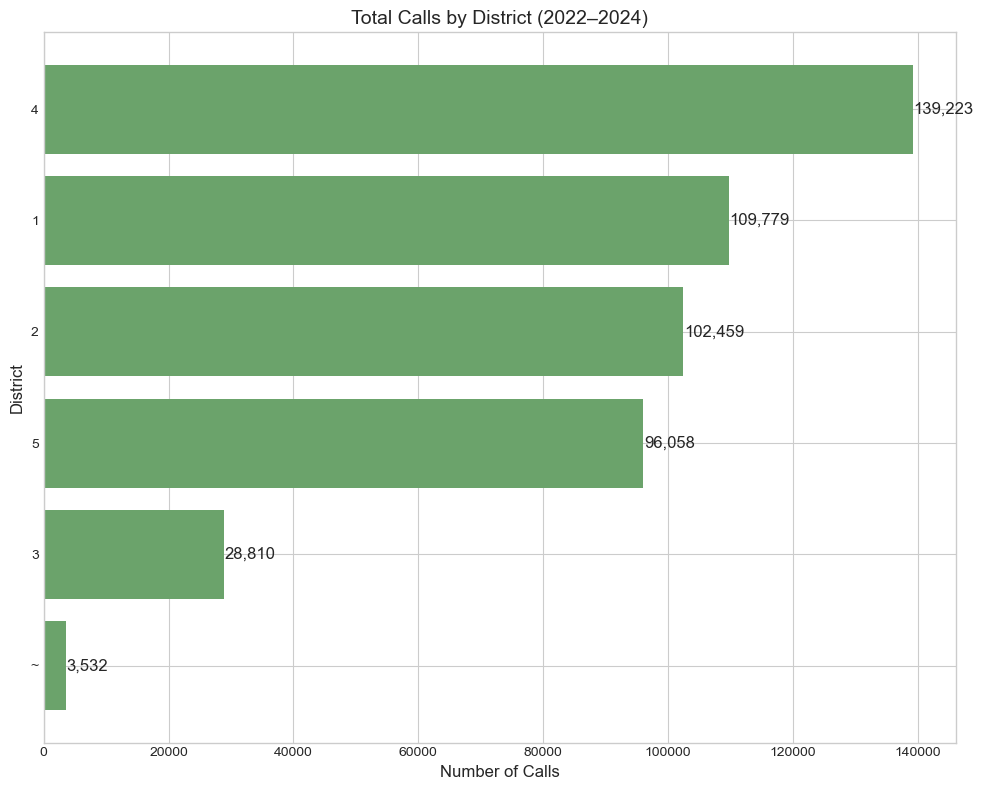

In [38]:


# --- Calls by District ---
calls_by_district = df.groupby("district").size().rename("Calls").sort_values(ascending=True)  # ascending for horizontal bar

fig, ax = plt.subplots(figsize=(10, 8))

# Horizontal bar chart
bars = ax.barh(calls_by_district.index, calls_by_district.values, color="#6BA36B")  # green bars

# Add call counts at the end of each bar
for bar in bars:
    width = bar.get_width()
    ax.text(width + 100, bar.get_y() + bar.get_height()/2, f"{int(width):,}",
            va='center', fontsize=12)  # adjust +100 if needed for spacing

ax.set_xlabel("Number of Calls", fontsize=12)
ax.set_ylabel("District", fontsize=12)
ax.set_title("Total Calls by District (2022–2024)", fontsize=14)

plt.tight_layout()
plt.show()


The top district servicing the calls is district 4 

### Top 10 Crimes Reported 

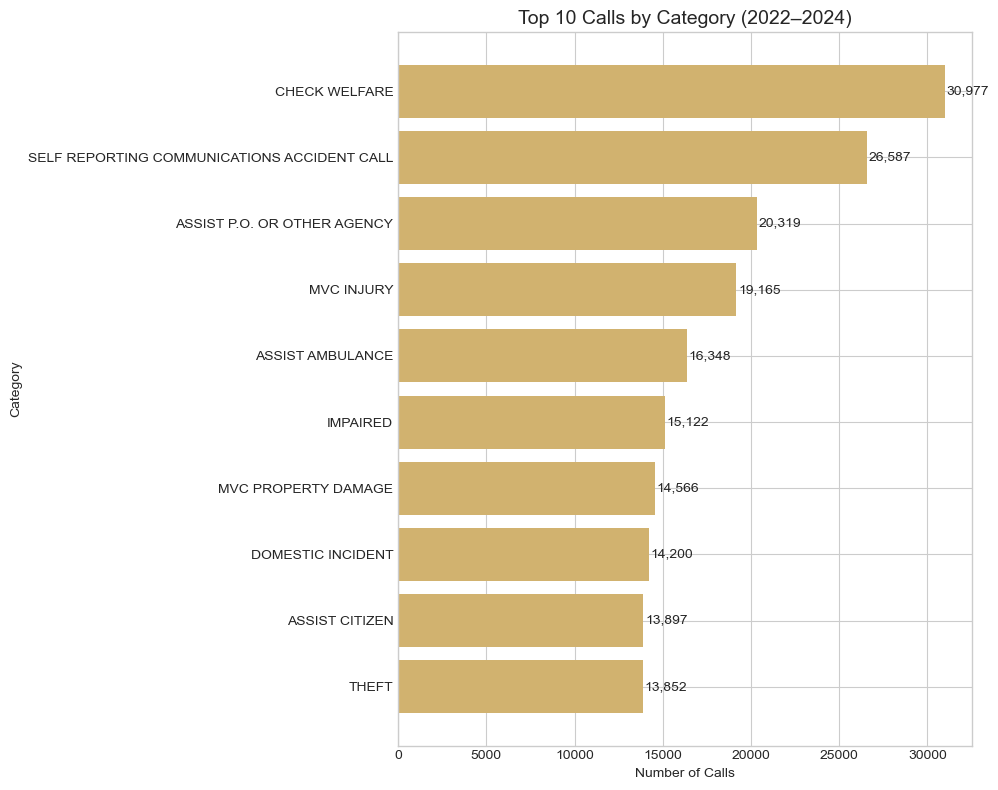

In [42]:


# --- Top 10 Calls by Category ---
calls_by_category = df.groupby("category").size().rename("Calls").sort_values(ascending=True)  # ascending for horizontal bar
top_10_category = calls_by_category.tail(10)  # get top 10 largest counts

fig, ax = plt.subplots(figsize=(10, 8))

# Horizontal bar chart, muted green color
bars = ax.barh(top_10_category.index, top_10_category.values, color="#D1B26F")

# Add call counts at the end of each bar
for bar in bars:
    width = bar.get_width()
    ax.text(width + 100, bar.get_y() + bar.get_height()/2, f"{int(width):,}",
            va='center', fontsize=10)

ax.set_xlabel("Number of Calls")
ax.set_ylabel("Category")
ax.set_title("Top 10 Calls by Category (2022–2024)", fontsize=14)

plt.tight_layout()
plt.show()


### YoY growth of Crime Types 

In [51]:


# --- 1. Aggregate calls per category per year ---
category_year = df.groupby(["category", "year"]).size().unstack(fill_value=0)

# Ensure all years are included
for yr in [2022, 2023, 2024]:
    if yr not in category_year.columns:
        category_year[yr] = 0

# --- 2. Overall totals per category ---
category_year['Overall Totals'] = category_year.sum(axis=1)

# --- 3. Calculate YoY (numeric) ---
category_year['2022 vs 2023 YoY'] = ((category_year[2023] - category_year[2022]) / category_year[2022] * 100).round(1)
category_year['2023 vs 2024 YoY'] = ((category_year[2024] - category_year[2023]) / category_year[2023] * 100).round(1)

# --- 4. Rename columns ---
category_year = category_year.rename(columns={
    2022: "2022 Total Calls",
    2023: "2023 Total Calls",
    2024: "2024 Total Calls"
})

# --- 5. Sort by 2024 Total Calls descending ---
category_year = category_year.sort_values(by="2024 Total Calls", ascending=False)

# --- 6. Format numbers and percentages ---
for col in ["2022 Total Calls","2023 Total Calls","2024 Total Calls","Overall Totals"]:
    category_year[col] = category_year[col].apply(lambda x: f"{int(x):,}")

for col in ["2022 vs 2023 YoY","2023 vs 2024 YoY"]:
    category_year[col] = category_year[col].apply(lambda x: f"{x:.0f}%" if pd.notnull(x) else "")

category_year = category_year.reset_index()

category_year


year,category,2022 Total Calls,2023 Total Calls,2024 Total Calls,Overall Totals,2022 vs 2023 YoY,2023 vs 2024 YoY
0,SELF REPORTING COMMUNICATIONS ACCIDENT CALL,"6,375","8,311","11,901","26,587",30%,43%
1,CHECK WELFARE,"9,251","10,192","11,534","30,977",10%,13%
2,MVC INJURY,"5,520","6,646","6,999","19,165",20%,5%
3,ASSIST P.O. OR OTHER AGENCY,"6,413","7,176","6,730","20,319",12%,-6%
4,ASSIST AMBULANCE,"5,182","5,311","5,855","16,348",2%,10%
...,...,...,...,...,...,...,...
150,COMPLAINT AREA DISORDERLY USE,1,0,0,1,-100%,
151,OUT OF REGION DEPLOYMENT,2,1,0,3,-50%,-100%
152,PROJECT READY,1,1,0,2,0%,-100%
153,EMOTIONALLY DISTURBED PERSON,"3,464","1,071",0,"4,535",-69%,-100%


### Which time of Day has the highest calls 
    

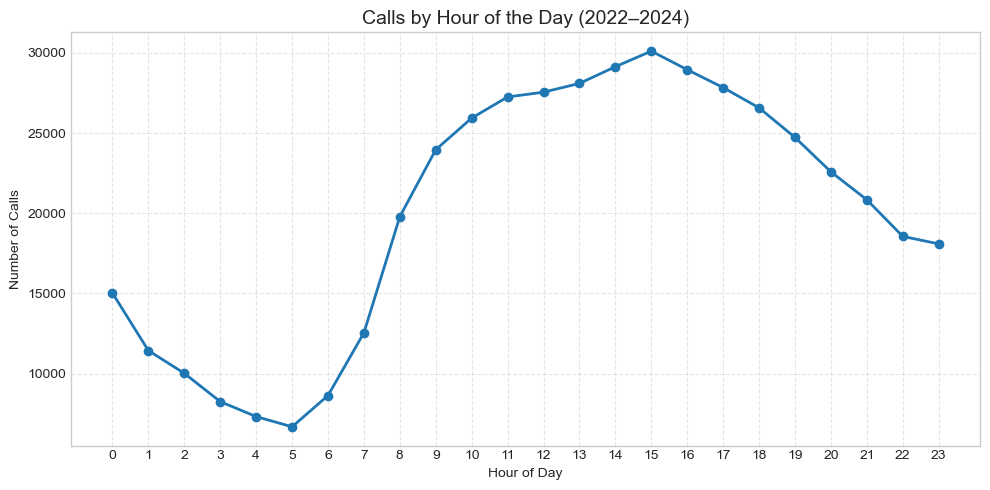

In [24]:


# --- 1. Ensure 'time' is datetime.time or extract hour ---
# If 'time' is object (HH:MM:SS), convert to datetime
df['time'] = pd.to_datetime(df['time'], format="%H:%M:%S", errors='coerce').dt.time

# Extract hour
df['hour'] = df['time'].apply(lambda x: x.hour if pd.notnull(x) else None)

# --- 2. Group by hour ---
calls_by_hour = df.groupby('hour').size().rename("Calls")

# --- 3. Plot ---
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(calls_by_hour.index, calls_by_hour.values, marker='o', color="#1f77b4", linewidth=2)

ax.set_title("Calls by Hour of the Day (2022–2024)", fontsize=14)
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Number of Calls")
ax.set_xticks(range(0,24))  # show all hours
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


Calls are higher in the afternoon and teters down during the evening thr highest calls happems between 1- 5pm with 3pm being the peak time.

### What are the sectors driving the most calls 

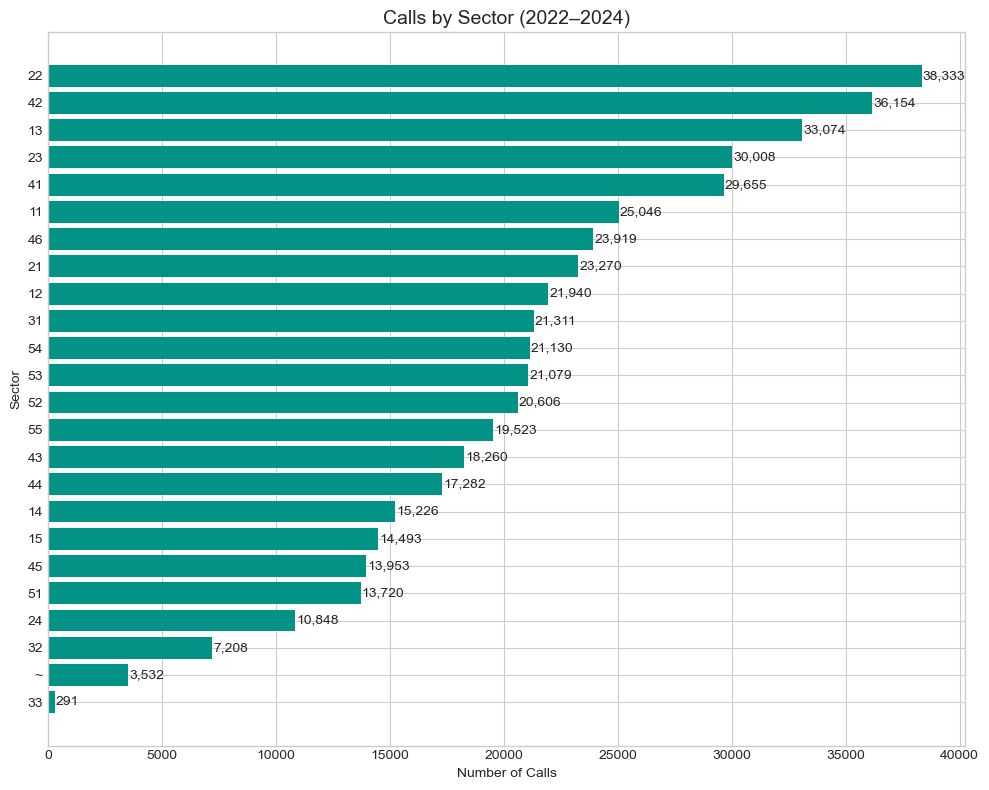

In [47]:

# --- Calls by Sector ---
calls_by_sector = df.groupby("sector").size().rename("Calls").sort_values(ascending=True)  # ascending for horizontal bar

fig, ax = plt.subplots(figsize=(10, 8))

# Horizontal bar chart, muted green color
bars = ax.barh(calls_by_sector.index, calls_by_sector.values, color="#029386")

# Add call counts at the end of each bar
for bar in bars:
    width = bar.get_width()
    ax.text(width + 50, bar.get_y() + bar.get_height()/2, f"{int(width):,}",
            va='center', fontsize=10)

ax.set_xlabel("Number of Calls")
ax.set_ylabel("Sector")
ax.set_title("Calls by Sector (2022–2024)", fontsize=14)

plt.tight_layout()
plt.show()

